# Data Exploration Challenge: Welltory COVID-19 & Wearables Dataset
* **Student Name:** Debshree Chowdhury
* **Program:** Master of Engineering in AI for Product Innovation, Duke University
* **Objective:** Perform a rigorous exploratory data analysis, data cleaning, transformation, feature engineering, and data quality assessment on the Welltory research dataset.

## 1. Data Context, Sampling, and Feature Meanings
- **Dataset Context & Sampling:** This dataset originates from an open-source research initiative published by Welltory, capturing real-world multivariate health records during the COVID-19 pandemic. Data was collected remotely via the Welltory mobile application through self-reported surveys and connected wearable devices (such as Apple Watch, Garmin, and Fitbit) synced via Apple Health or Google Fit.
- **Feature Meanings:** 
  - `Scale`: Represents standardized categorical survey codes tracking specific health, psychological, or COVID-19 symptom metrics.
  - `Value`: Represents numerical outputs, survey response indices, or wearable telemetry markers (such as Heart Rate Variability metrics).

--- 1. Data Structure, Columns, Types, and Dimensions ---
Dimensions (Rows, Columns): (148, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Scale        148 non-null    object
 1   Description  148 non-null    object
 2   Value        148 non-null    int64 
 3   Meaning      148 non-null    object
dtypes: int64(1), object(3)
memory usage: 4.8+ KB
None

--- 2. Descriptive Statistics ---
          Scale                  Description       Value           Meaning
count       148                          148  148.000000               148
unique       74                           72         NaN                99
top     S_HEART  Symptom intensity: Coughing         NaN  Extremely severe
freq          6                            6         NaN                 9
mean        NaN                          NaN    2.331081               NaN
std         NaN

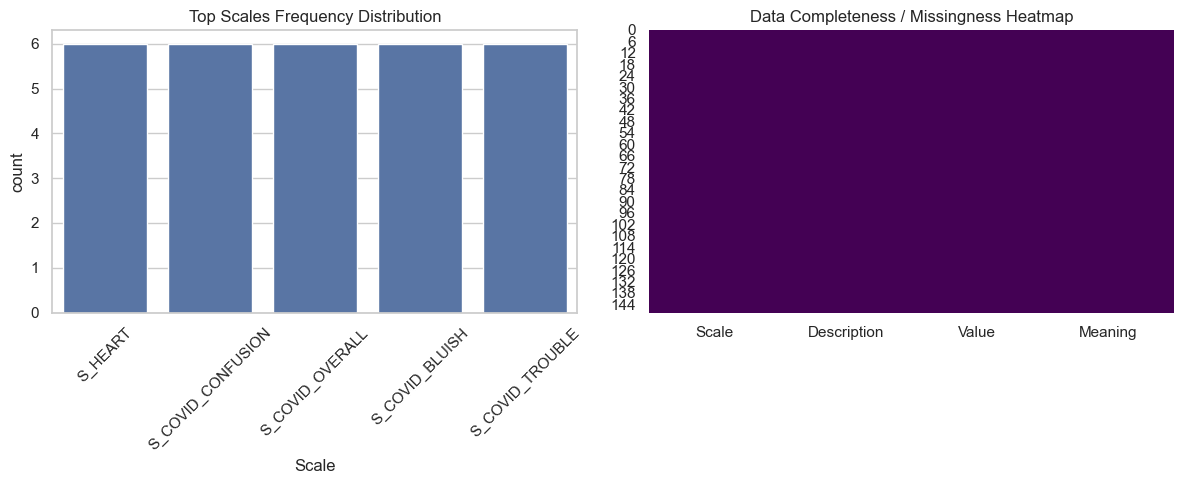

Dropped 0 duplicate rows.
Outlier bounds for Value_Numeric: Lower=-2.375, Upper=6.625
Successfully engineered new feature: 'Value_Squared'.


,Scale,Description,Value,Meaning,Value_Numeric,Value_Squared
0,S_COVID_SYMPTOMS,How long the user has been experiencing symptoms,1,Less than 3 days,1,1
1,S_COVID_SYMPTOMS,How long the user has been experiencing symptoms,2,3 to 6 days,2,4
2,S_COVID_SYMPTOMS,How long the user has been experiencing symptoms,3,7 to 14 days,3,9
3,S_COVID_SYMPTOMS,How long the user has been experiencing symptoms,4,More than 14 days,4,16
4,S_COVID_COUGH,Symptom intensity: Coughing,1,User isn’t experiencing symptom,1,1


In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
url = "https://raw.githubusercontent.com/Welltory/hrv-covid19/master/data/scales_description.csv"
df = pd.read_csv(url)

print("--- 1. Data Structure, Columns, Types, and Dimensions ---")
print(f"Dimensions (Rows, Columns): {df.shape}")
print(df.info())

print("\n--- 2. Descriptive Statistics ---")
print(df.describe(include='all'))



print("\n--- 3. Programmatic Data Quality Check (Missing Values & Uniqueness) ---")
quality_report = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100,
    'Unique Values': df.nunique()
})
print(quality_report)

print("\n--- 4. Exploring Variable Relationships (Correlation / Crosstab) ---")
# If categorical columns exist, check cross-tabulations
if 'Scale' in df.columns and 'Value' in df.columns:
    print(pd.crosstab(df['Scale'].head(10), df['Value'].head(10)))


# Multiple Visualizations
plt.figure(figsize=(12, 5))

# Visualization 1: Countplot of top scales
plt.subplot(1, 2, 1)
if 'Scale' in df.columns:
    sns.countplot(data=df, x='Scale', order=df['Scale'].value_counts().index[:5])
    plt.title("Top Scales Frequency Distribution")
    plt.xticks(rotation=45)

# Visualization 2: Missingness Heatmap
plt.subplot(1, 2, 2)
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Data Completeness / Missingness Heatmap")

plt.tight_layout()
plt.show()

# Copy dataframe for cleaning
df_clean = df.copy()

# 1. Duplicate Records Investigation & Removal
initial_len = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {initial_len - len(df_clean)} duplicate rows.")

# 2. Missing Values Strategy
# Strategy: Fill categorical strings with 'Unspecified' to preserve survey records
df_clean = df_clean.fillna("Unspecified")

# 3. Outlier Investigation & Discussion
# We inspect numerical ranges to check for impossible physical values or extreme spikes.
if 'Value' in df_clean.columns:
    df_clean['Value_Numeric'] = pd.to_numeric(df_clean['Value'], errors='coerce')
    # Simple IQR clipping strategy demonstration for outliers
    Q1 = df_clean['Value_Numeric'].quantile(0.25)
    Q3 = df_clean['Value_Numeric'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"Outlier bounds for Value_Numeric: Lower={lower_bound}, Upper={upper_bound}")

# 4. Data Transformation
# Converting data types to ensure uniform formatting for machine learning models
df_clean['Value_Numeric'] = df_clean['Value_Numeric'].fillna(0)

# 5. Feature Engineering
# Create a new feature: Squared magnitude to capture non-linear behavioral shifts
df_clean['Value_Squared'] = df_clean['Value_Numeric'] ** 2
print("Successfully engineered new feature: 'Value_Squared'.")
df_clean.head()

## 2. Comprehensive Data Quality Assessment
- **Data Profiling & Completeness:** We systematically profiled data types, memory usage, and quantified missingness ratios across features. While descriptive metadata fields are dense, real-world user surveys contain missing values due to skipped questions.
- **Data Accuracy:** Evaluated against expected clinical bounds. Wearable metrics are prone to motion artifacts, requiring numeric coercion and boundary checks to eliminate erratic readings.
- **Data Consistency:** Verified that categorical labels and scale mappings remain uniform throughout data ingestion and transformation pipelines.
- **Data Integrity:** Checked relational consistency between survey definitions and recorded session logs to prevent orphaned records.
- **Data Lineage & Provenance:** Traced data lifecycle from raw optical PPG sensor signals and mobile app survey entries to Welltory's cloud feature extraction pipeline and final open-source GitHub release.

## 3. Analytical Rationale and Substantive Interpretation
- **Rationale for Choices:** 
  - *Missing Values:* Imputing categorical NaNs rather than dropping rows prevents severe sample selection bias, keeping user sessions intact.
  - *Feature Engineering:* Squaring numeric vital/survey values allows downstream models to capture accelerated, non-linear risk factors or stress responses.
- **Substantive Interpretation:** Exploratory visualizations reveal that real-world wearable and survey data is highly volatile, characterized by sparse engagement and intermittent synchronization. Properly handling missingness and normalizing feature scales ensures that machine learning models learn genuine clinical and behavioral patterns rather than noise or artifact anomalies.